In [1]:
pip install pmdarima

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [2]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential
from keras.layers import LSTM, Dense
from sklearn.metrics import r2_score

In [3]:
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()
data = pd.read_csv(io.StringIO(uploaded['Brent Oil Futures Historical Data.csv'].decode('utf-8')))

Saving Brent Oil Futures Historical Data.csv to Brent Oil Futures Historical Data (1).csv


<Axes: >

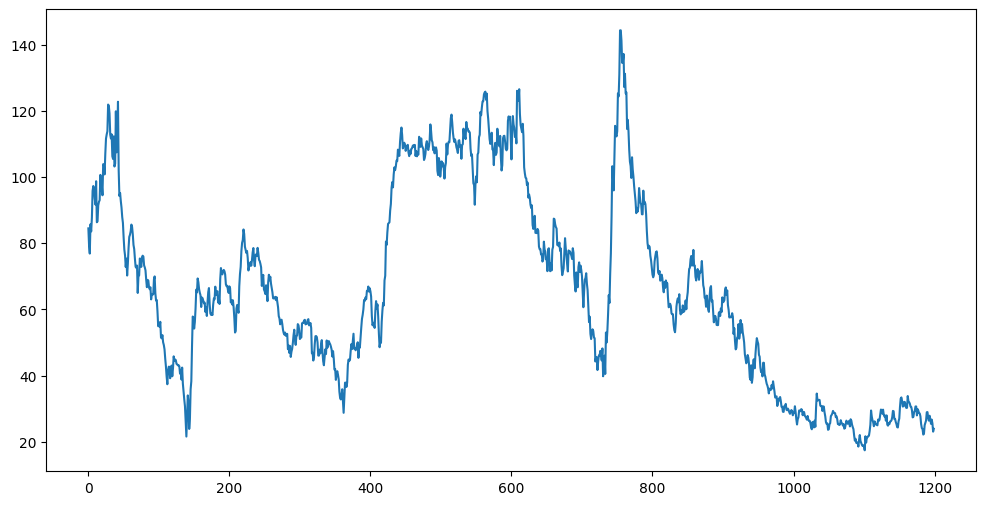

In [4]:
data["Open"].plot(figsize=(12,6))

In [5]:
# Dickey - Fuller Test
from statsmodels.tsa.stattools import adfuller

def ad_test(dataset):
  dftest = adfuller(dataset, autolag ='AIC')
  print("1. ADF: ", dftest[0])
  print("2. p-value: ", dftest[1])
  print("3. No. of lags: ", dftest[2])
  print("4. No. of observations used for ADF Regression and Critical Values Calculations: ", dftest[3])
  print("5. Critical Values: ")
  for key, val in dftest[4].items():
    print("\t", key, ",", val)

In [6]:
ad_test(data['Price'])

1. ADF:  -2.141224626138249
2. p-value:  0.22826416807416533
3. No. of lags:  10
4. No. of observations used for ADF Regression and Critical Values Calculations:  1189
5. Critical Values: 
	 1% , -3.435861752677197
	 5% , -2.8639738850277796
	 10% , -2.568065847341873


In [7]:
from pmdarima import auto_arima
import warnings
warnings.filterwarnings("ignore")

In [8]:
stepwise_fit = auto_arima(data['Price'], trace=True, suppress_warnings=True)
stepwise_fit.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=6111.492, Time=4.07 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=6116.654, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=6118.609, Time=0.26 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=6118.610, Time=0.44 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=6114.997, Time=0.08 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=6112.914, Time=1.46 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=6113.451, Time=2.10 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=6113.404, Time=3.96 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=6113.596, Time=2.91 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=6120.595, Time=1.61 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=6111.854, Time=2.90 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=6111.645, Time=2.32 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=6114.034, Time=8.12 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=6109.731, Time=0.48 sec
 ARIMA(1,1,2)(0,0,0)[0]          

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1200
Model:               SARIMAX(2, 1, 2)   Log Likelihood               -3049.865
Date:                Sat, 10 Jun 2023   AIC                           6109.731
Time:                        07:57:40   BIC                           6135.177
Sample:                             0   HQIC                          6119.317
                               - 1200                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.5313      0.167      9.146      0.000       1.203       1.859
ar.L2         -0.6524      0.153     -4.251      0.000      -0.953      -0.352
ma.L1         -1.5474      0.159     -9.708      0.000      -1.860      -1.235
ma.L2          0.6968      0.140      4.969      0.000       0.422       0.972
sigma2         9.4821      0.215     44.025      0.000       9.060       9.904
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              1368.56
Prob(Q):                              1.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.31   Skew:                             0.56
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.11
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [9]:
# Convert the "date" column to a datetime object
data['Date'] = pd.to_datetime(data['Date'])

In [10]:
# Drop the columns you don't need
data = data.drop(["Change %"], axis=1)

In [11]:
# Convert "Vol." column to float datatype with suffix conversion
data['Vol.'] = data['Vol.'].str.replace('M', 'e6').str.replace('K', 'e3').astype(float)
print(data.dtypes)

Date     datetime64[ns]
Price           float64
Open            float64
High            float64
Low             float64
Vol.            float64
dtype: object


In [12]:
import statsmodels.api as sm

In [13]:
"""
# Spllitting the dataset
print(data.shape)
train=data.iloc[:-30]
test=data.iloc[-30:]
print(train.shape, test.shape)
"""

'\n# Spllitting the dataset\nprint(data.shape)\ntrain=data.iloc[:-30]\ntest=data.iloc[-30:]\nprint(train.shape, test.shape)\n'

In [14]:
# extract features and target
X = data[['Open', 'High', 'Low','Vol.']]
y = data['Price']

In [15]:
# Addition
# Select the rows for the training set (2000-2019)
train_X = X[data['Date'].dt.year.between(2000, 2019)]
train_y = y[data['Date'].dt.year.between(2000, 2019)]

# Select the rows for the test set (2020-2022)
test_X = X[data['Date'].dt.year.between(2020, 2022)]
test_y = y[data['Date'].dt.year.between(2020, 2022)]

In [16]:
# Taining the model
model=sm.tsa.arima.ARIMA(train_y, order=(1,0,5))
model=model.fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Price   No. Observations:                 1044
Model:                 ARIMA(1, 0, 5)   Log Likelihood               -2563.300
Date:                Sat, 10 Jun 2023   AIC                           5142.601
Time:                        07:57:42   BIC                           5182.207
Sample:                             0   HQIC                          5157.623
                               - 1044                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         64.9429     19.710      3.295      0.001      26.311     103.575
ar.L1          0.9940      0.003    296.430      0.000       0.987       1.001
ma.L1          0.0214      0.022      0.951      0.342      -0.023       0.065
ma.L2          0.0389      0.025      1.531      0.126      -0.011       0.089
ma.L3          0.0329      0.023      1.438      0.151      -0.012       0.078
ma.L4          0.0335      0.021      1.627      0.104      -0.007       0.074
ma.L5          0.0380      0.024      1.569      0.117      -0.009       0.085
sigma2         7.9101      0.217     36.379      0.000       7.484       8.336
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):               949.78
Prob(Q):                              0.92   Prob(JB):                         0.00
Heteroskedasticity (H):               0.54   Skew:                             0.92
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.30
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [17]:
# Make predictions on the Test dataset
start = len(train_y)
end = len(test_y) + len(test_y)-1
pred = model.predict(start=start, end=end, type='levels')
print(pred)
pred.index = data.index[start:end+1]
print(pred)

312     55.475678
313     57.123595
314     56.863730
315     55.219864
316     55.244555
          ...    
463    109.663964
464    108.943951
465    109.358748
466    106.133236
467    107.581023
Name: predicted_mean, Length: 156, dtype: float64
156     55.475678
157     57.123595
158     56.863730
159     55.219864
160     55.244555
          ...    
307    109.663964
308    108.943951
309    109.358748
310    106.133236
311    107.581023
Name: predicted_mean, Length: 156, dtype: float64


<Axes: >

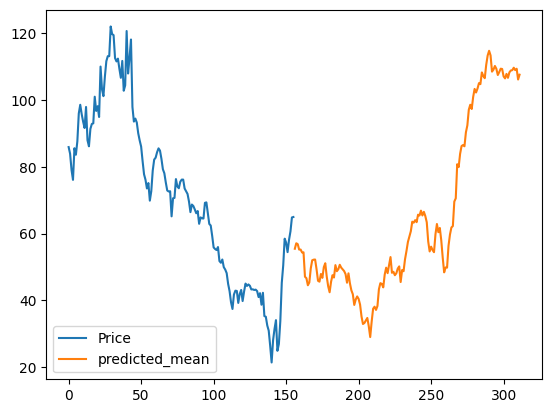

In [18]:
# Plotting the predicted values and the test set
test_y.plot(legend=True)
pred.plot(legend=True)

In [19]:
test_y.mean()

71.18711538461538

In [20]:
from sklearn.metrics import mean_squared_error
from math import sqrt

rmse=sqrt(mean_squared_error(test_y, pred))
print(rmse)

48.01754587070513
